# 01 — Preprocessing (R / Seurat)

Loads the query Seurat object from `00_data_acquisition.ipynb`, applies QC filters, re-runs normalisation, HVG selection, PCA and saves the filtered object.


In [1]:
# Papermill parameter cell — injected at runtime from config/params.yaml
min_genes    <- 200L
max_genes    <- 2500L
max_pct_mito <- 20
output_path  <- "data/cca/query.rds"
query_path   <- "data/cca/query.rds"


In [2]:
# Parameters
query_path = "data/cca/query_su001.rds"
min_genes = 200
max_genes = 4000
max_pct_mito = 25
output_path = "data/cca/query_su001.rds"


In [3]:
suppressPackageStartupMessages({
  library(Seurat)
  library(ggplot2)
  library(patchwork)
  library(dplyr)
})
set.seed(42)
options(repr.plot.width = 9, repr.plot.height = 4)  # compact figures
cat(sprintf("Seurat %s | R %s\n", packageVersion("Seurat"), R.version$major))

Seurat 5.5.0 | R 4


## 1 · Load Data

In production: `Read10X(data.dir)` → `CreateSeuratObject()`.  
Here we load the built-in PBMC3k dataset from `SeuratData`.

In [4]:
# Load query Seurat object produced by 00_data_acquisition.ipynb
stopifnot(file.exists(query_path))
seurat_obj <- readRDS(query_path)
cat(sprintf("Loaded: %d cells x %d genes  (from %s)\n",
            ncol(seurat_obj), nrow(seurat_obj), query_path))


Loaded: 4905 cells x 17865 genes  (from data/cca/query_su001.rds)


## 2 · Quality Control

Flag mitochondrial genes (`^MT-`), calculate per-cell QC metrics, visualise and filter.

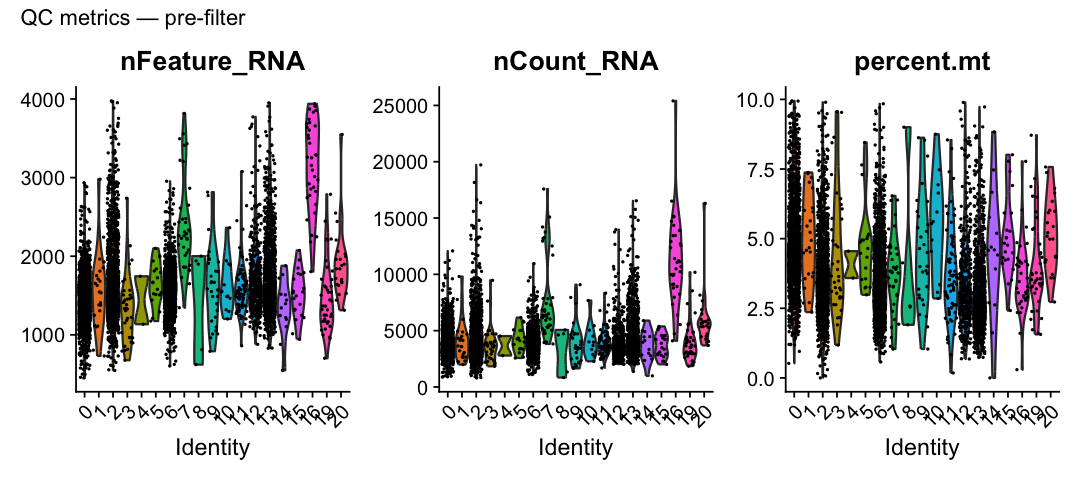

In [5]:
seurat_obj[["percent.mt"]] <- PercentageFeatureSet(seurat_obj, pattern = "^MT-")

# Violin plots
VlnPlot(
  seurat_obj,
  features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
  ncol = 3, pt.size = 0.1
) + plot_annotation(title = "QC metrics — pre-filter")

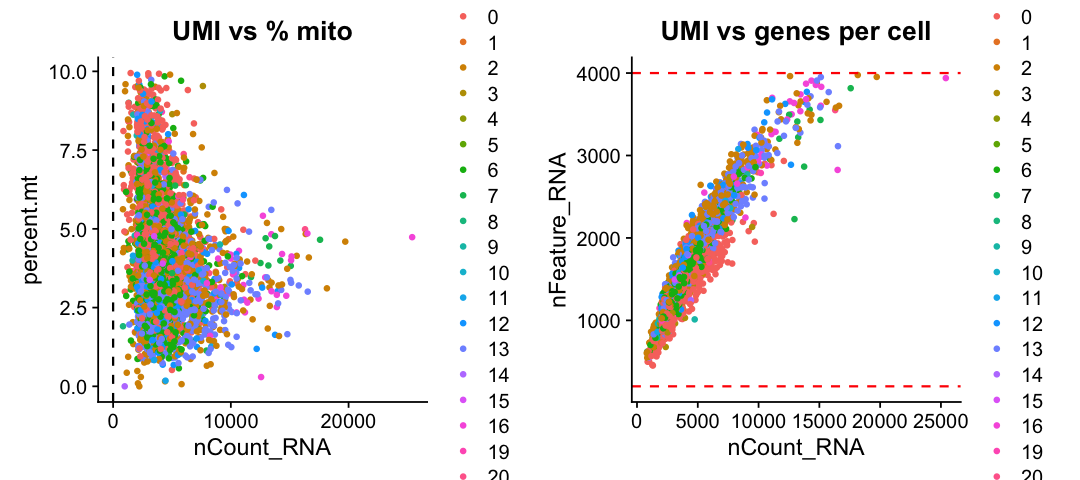

In [6]:
# Feature scatter: spot outliers
p1 <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "percent.mt") +
      geom_vline(xintercept = 0, linetype = "dashed") +
      ggtitle("UMI vs % mito")
p2 <- FeatureScatter(seurat_obj, feature1 = "nCount_RNA", feature2 = "nFeature_RNA") +
      geom_hline(yintercept = c(min_genes, max_genes), linetype = "dashed", colour = "red") +
      ggtitle("UMI vs genes per cell")
p1 + p2

In [7]:
n_before <- ncol(seurat_obj)
seurat_obj <- subset(
  seurat_obj,
  subset = nFeature_RNA > min_genes &
           nFeature_RNA < max_genes &
           percent.mt  < max_pct_mito
)
cat(sprintf(
  "Cells before QC filter : %d\nCells after QC filter  : %d\nRemoved                : %d (%.1f%%)\n",
  n_before, ncol(seurat_obj), n_before - ncol(seurat_obj), (n_before - ncol(seurat_obj)) / n_before * 100
))

Cells before QC filter : 4905
Cells after QC filter  : 4905
Removed                : 0 (0.0%)


## 3 · Doublet Detection

In production use **DoubletFinder** (`install.packages('DoubletFinder')`) or **scDblFinder**.  
Here we simulate a doublet probability score (Beta(1,10)) and remove cells > 0.25.

In [8]:
# --- Production replacement ---
# library(DoubletFinder)
# seurat_obj <- doubletFinder(seurat_obj, PCs = 1:30, pN = 0.25, pK = 0.09, nExp = ...)
# --------------------------------

set.seed(42)
doublet_score <- rbeta(ncol(seurat_obj), shape1 = 1, shape2 = 10)
seurat_obj$doublet_score     <- doublet_score
seurat_obj$predicted_doublet <- doublet_score > 0.25

n_dbl <- sum(seurat_obj$predicted_doublet)
cat(sprintf("Predicted doublets: %d (%.1f%%)\n", n_dbl, n_dbl / ncol(seurat_obj) * 100))

seurat_obj <- subset(seurat_obj, subset = predicted_doublet == FALSE)
cat(sprintf("Cells after doublet removal: %d\n", ncol(seurat_obj)))

Predicted doublets: 289 (5.9%)


Cells after doublet removal: 4616


## 4 · Normalisation & Log-transform

Library-size normalise to 10,000 counts per cell, then log1p-transform.

In [9]:
seurat_obj <- NormalizeData(
  seurat_obj,
  normalization.method = "LogNormalize",
  scale.factor         = 1e4
)
cat("Normalisation complete (LogNormalize, scale.factor = 10,000)\n")

Normalizing layer: counts



Normalisation complete (LogNormalize, scale.factor = 10,000)


## 5 · Highly Variable Gene (HVG) Selection

Finding variable features for layer counts



HVGs selected: 2000
Top 10: TRBV7-2, CXCL13, TRBV12-3, TRBV4-2, TRBV20-1, TRBV30, TRBV7-9, TRBV13, TRBV4-1, GNLY


When using repel, set xnudge and ynudge to 0 for optimal results



Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


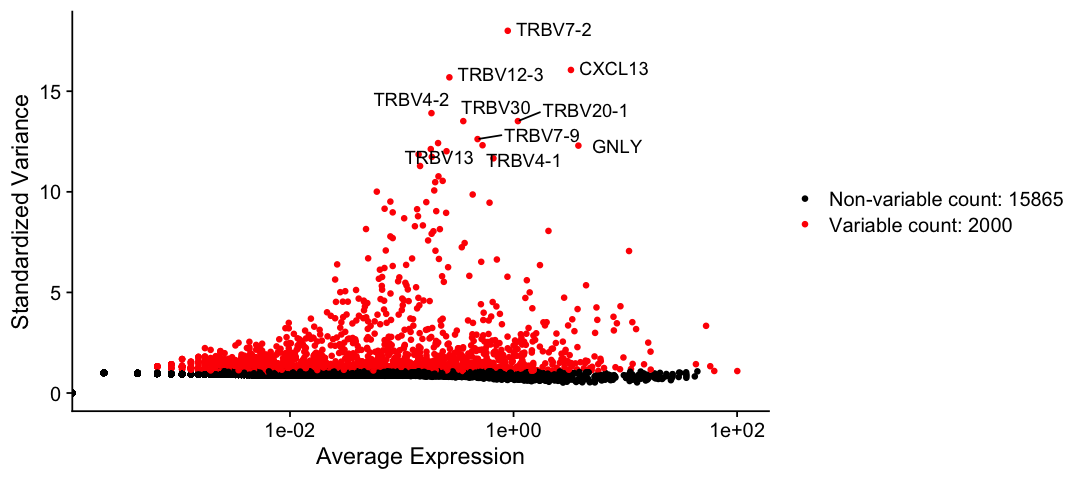

In [10]:
seurat_obj <- FindVariableFeatures(
  seurat_obj,
  selection.method = "vst",
  nfeatures        = 2000
)

top10 <- head(VariableFeatures(seurat_obj), 10)
cat(sprintf("HVGs selected: %d\nTop 10: %s\n",
            length(VariableFeatures(seurat_obj)), paste(top10, collapse = ", ")))

p_hvg <- VariableFeaturePlot(seurat_obj)
LabelPoints(plot = p_hvg, points = top10, repel = TRUE)

## 6 · Scaling & PCA

Scale HVGs (zero-mean, unit-variance), run PCA with 50 components.

Centering and scaling data matrix



Warning message:
“Different features in new layer data than already exists for scale.data”


Top genes per PC:


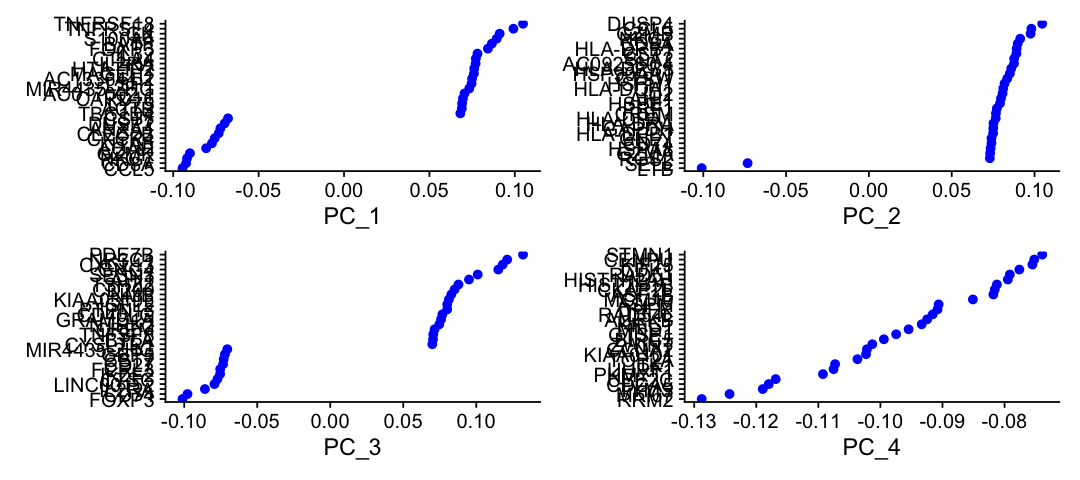

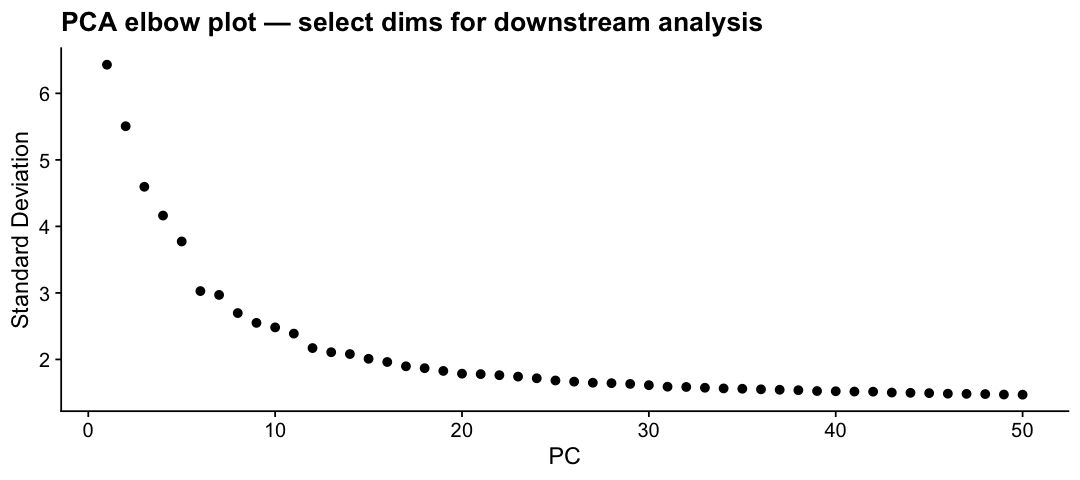

In [11]:
seurat_obj <- ScaleData(seurat_obj, features = VariableFeatures(seurat_obj))

seurat_obj <- RunPCA(
  seurat_obj,
  features = VariableFeatures(seurat_obj),
  npcs     = 50,
  verbose  = FALSE
)

cat("Top genes per PC:\n")
print(VizDimLoadings(seurat_obj, dims = 1:4, reduction = "pca"))

ElbowPlot(seurat_obj, ndims = 50) +
  ggtitle("PCA elbow plot — select dims for downstream analysis")

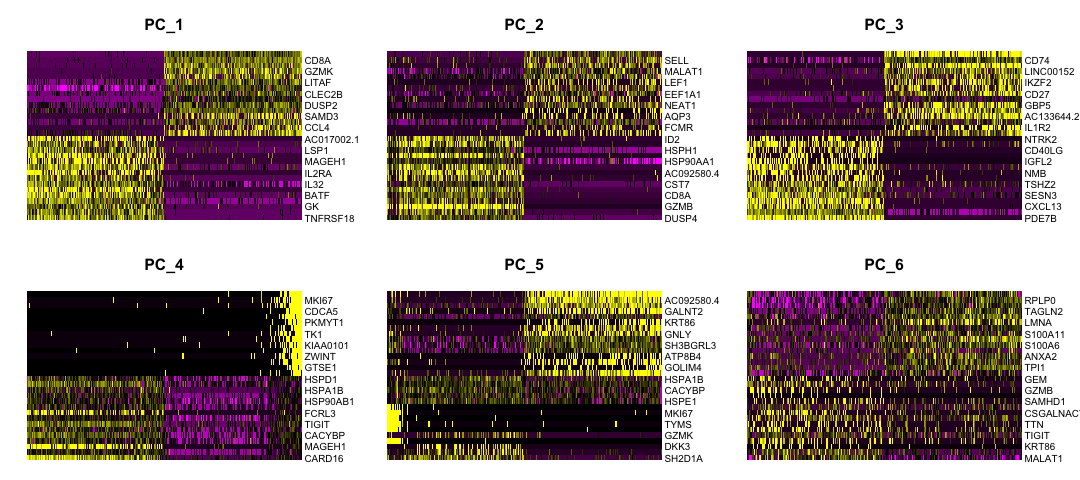

In [12]:
# Examine top PCs
DimHeatmap(seurat_obj, dims = 1:6, cells = 500, balanced = TRUE)

## 7 · Save Pre-processed Seurat Object

In [13]:
dir.create(dirname(output_path), showWarnings = FALSE, recursive = TRUE)
saveRDS(seurat_obj, file = output_path)

cat(sprintf("Saved Seurat object → %s\n", output_path))
cat(sprintf("Final dataset : %d cells x %d HVGs\n", ncol(seurat_obj), length(VariableFeatures(seurat_obj))))
cat(sprintf("PCA dims      : %d\n", ncol(Embeddings(seurat_obj, 'pca'))))

# Summary of object
seurat_obj

Saved Seurat object → data/cca/query_su001.rds


Final dataset : 4616 cells x 2000 HVGs


PCA dims      : 50


An object of class Seurat 
17865 features across 4616 samples within 1 assay 
Active assay: RNA (17865 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap